<a href="https://colab.research.google.com/github/Gao-Mm/quant-work/blob/main/portfolio_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analytics of Equity Data

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#read and explore data
eq_df =pd.read_csv('//content//stocks.csv')
eq_df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
...,...,...,...,...,...,...,...,...
243,GOOG,2023-05-01,107.720001,108.680000,107.500000,107.709999,107.709999,20926300
244,GOOG,2023-05-02,107.660004,107.730003,104.500000,105.980003,105.980003,20343100
245,GOOG,2023-05-03,106.220001,108.129997,105.620003,106.120003,106.120003,17116300
246,GOOG,2023-05-04,106.160004,106.300003,104.699997,105.209999,105.209999,19780600


In [4]:
#get summary of data
eq_df.groupby("Ticker").describe()

Open                                                             \
       count        mean        std         min         25%         50%   
Ticker                                                                    
AAPL    62.0  157.779839   7.224608  144.380005  151.489998  158.400002   
GOOG    62.0  100.381919   6.197598   89.540001   94.532499  102.680000   
MSFT    62.0  274.735969  17.324808  246.550003  257.410004  277.110001   
NFLX    62.0  328.110643  18.467142  287.339996  317.137497  325.649994   

                                High              ...   Adj Close              \
               75%         max count        mean  ...         75%         max   
Ticker                                            ...                           
AAPL    164.702503  170.979996  62.0  159.473710  ...  165.162506  173.570007   
GOOG    105.859999  107.800003  62.0  101.792516  ...  105.962503  109.459999   
MSFT    285.825005  307.760010  62.0  277.764356  ...  287.217506  310.649994   
NFLX    340.674995  372.410004  62.0  332.648065  ...  338.899994  366.829987   

       Volume                                                                  \
        count          mean           std         min         25%         50%   
Ticker                                                                          
AAPL     62.0  6.028296e+07  1.430605e+07  41516200.0  49607025.0  56094550.0   
GOOG     62.0  3.072537e+07  1.422509e+07  16732000.0  22406175.0  27205200.0   
MSFT     62.0  3.084835e+07  1.109188e+07  17150300.0  23392350.0  27340000.0   
NFLX     62.0  6.471732e+06  3.416398e+06   2657900.0   4623600.0   5639750.0   

                                 
               75%          max  
Ticker                           
AAPL    68376175.0  113316400.0  
GOOG    32743500.0   97798600.0  
MSFT    34324100.0   69527400.0  
NFLX     6883500.0   22128300.0  

[4 rows x 48 columns]

In [5]:
#check data types
eq_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


# Data Cleaning
To clean the data the following steps were taken:

*   Change date and ticker data types
*   Check for duplicates

In [6]:
#change date data type from object
eq_df["Date"]=pd.to_datetime(eq_df["Date"])
#change  data type ticker type to string
eq_df["Ticker"]=eq_df["Ticker"].astype('string')

In [7]:
#check data type again
eq_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Ticker     248 non-null    string        
 1   Date       248 non-null    datetime64[ns]
 2   Open       248 non-null    float64       
 3   High       248 non-null    float64       
 4   Low        248 non-null    float64       
 5   Close      248 non-null    float64       
 6   Adj Close  248 non-null    float64       
 7   Volume     248 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1), string(1)
memory usage: 15.6 KB


In [8]:
#check missing values
eq_df.isnull().sum()


,0
Ticker,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [9]:
#remove duplicates
eq_df.duplicated().sum()

np.int64(0)

In [10]:
#make a dataframe of a portfolio of stocks
df_portfolio = eq_df.pivot_table(index="Date",
                                columns="Ticker",
                                 values="Adj Close",
                                 aggfunc="last")
df_portfolio

Ticker,AAPL,GOOG,MSFT,NFLX
Date,,,,
2023-02-07,154.414230,108.040001,266.891510,362.950012
2023-02-08,151.688400,100.000000,266.063599,366.829987
2023-02-09,150.639999,95.459999,262.961365,362.500000
2023-02-10,151.009995,94.860001,262.442657,347.359985
2023-02-13,153.850006,95.000000,270.642120,358.570007
...,...,...,...,...
2023-05-01,169.589996,107.709999,305.559998,324.119995
2023-05-02,168.539993,105.980003,305.410004,317.549988
2023-05-03,167.449997,106.120003,304.399994,319.299988


# Normalize To Hundred
To make securities directly comparable its important to normalize the data to 100. This allows investor(s) to analyse the performance overtime from a relative starting point.

In [11]:
df_portfolio.iloc[0]

,2023-02-07
Ticker,
AAPL,154.414230
GOOG,108.040001
MSFT,266.891510
NFLX,362.950012


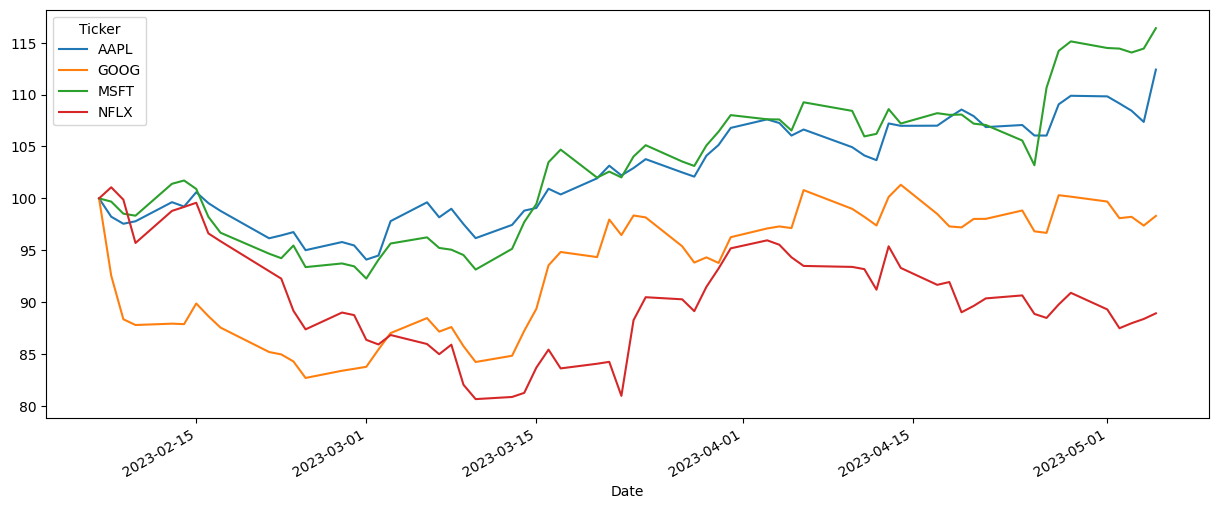

In [12]:
(df_portfolio/df_portfolio.iloc[0]*100).plot(figsize=(15, 6));
plt.show()

# Line Graph Analytics

The stock prices drop on 15 Febuary 2023, may have been caused by the fears of the feds aggressive tax hike policies during this time.
On 1 March 2023, there was another drop in prices with Netflix becoming the lowest performing security. With a growing fear of recession during this time, the DJI dropping 0.7% ans S&P 500 dropping 0.3%.
From 15 March 2023, prices started rising with Microsoft performing relatively well compared to the other securities, closely followed by Apple, then Google and lastly Netflix.


# Return of Portfolio Of Securities
The gain or loss of the portfolio helps invester(s) evaluate the performance of their investemnt over a specified period of time.This can be used to compare to performance goals and whether the reward is worth the risk.

In [13]:
#calculate simple returns for the securities in the portfolio
simple_returns = (df_portfolio / df_portfolio.shift(1)) - 1
simple_returns.head(5)

Ticker,AAPL,GOOG,MSFT,NFLX
Date,,,,
2023-02-07,NaN,NaN,NaN,NaN
2023-02-08,-0.017653,-0.074417,-0.003102,0.010690
2023-02-09,-0.006912,-0.045400,-0.011660,-0.011804
2023-02-10,0.002456,-0.006285,-0.001973,-0.041766
2023-02-13,0.018807,0.001476,0.031243,0.032272


In [15]:
#assume the weights of the portfolio as follows
#AAPL - 0.25, GOOG - 0.25, MSFT - 0.30, NFLX - 0.20
weights = np.array([0.25, 0.25, 0.30, 0.20])
#get dot product
np.dot(simple_returns, weights)
#get annual returns of each security
ann_returns = simple_returns.mean()* 250
ann_returns

,0
Ticker,
AAPL,0.504137
GOOG,-0.016702
MSFT,0.661629
NFLX,-0.419099


In [16]:
#get dot product
np.dot(ann_returns, weights)

np.float64(0.23652761252274607)

In [19]:
#calculate porfolio return (%)
portfolio_return = str(round(np.dot(ann_returns, weights), 5)* 100) + '%'
print(portfolio_return)

23.653%
